
 Régression Linéaire
RMSE Régression Linéaire : 1.4236757362485557
R² score Régression Linéaire : 0.22484871667672846

 Random forest
RMSE Random forest : 1.3418636914897404
R² score Random forest : 0.3882475125281163


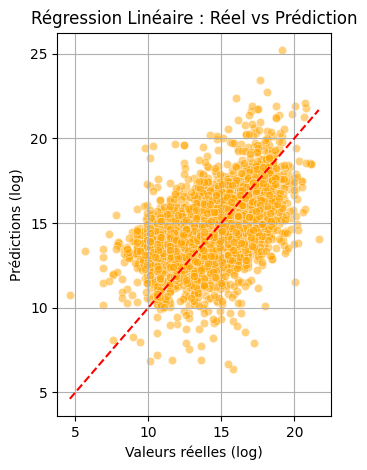

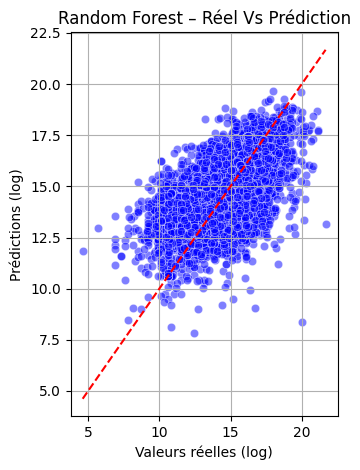

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
#from xgboost import XGBRegressor


# Chargement fichier + encodage
path = "/Users/amar/Desktop/Alyra_School/Alyra 2025/4- Projet/investments_VC.csv"
df = pd.read_csv(path, encoding='unicode_escape')

# Suppression des espaces avant et après
df.columns = df.columns.str.strip().str.lower()

# Sélection des colonnes utiles
colonnes = ['country_code', 'market', 'category_list', 'founded_year', 'funding_rounds', 'funding_total_usd']
df = df[colonnes]

# Nettoyage funding_total_usd (suppresion des $ et des "," -> remplacer par '')
df['funding_total_usd'] = df['funding_total_usd'].replace(r'[\$,]', '', regex=True) #regex=true -> expression réguliere et non une chaine exacte à chercher

# Transformation string-> float/int si ko -> NaN 
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'], errors='coerce') 

# Suppression du dataframe des lignes avec données manquantes ou montant nul
df.dropna(inplace=True)
df = df[df['funding_total_usd'] > 0]

# Changement d'échelle via LOG (log pour atténuer les extrêmes) + définiton de la variable cible
df['log_funding'] = np.log1p(df['funding_total_usd'])
y = df['log_funding']

# Variables explicatives : encodage One-Hot aux colonnes catégorielles -> chaque valeur unique dans une colonne 
# devient une nouvelle colonne contenant 0 ou 1 
# Création de la matrice X
X = pd.get_dummies(df[['country_code', 'market', 'category_list', 'founded_year', 'funding_rounds']], drop_first=True)

# Split des données d'entrainement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#------------
# REGRESSION LINEAIRE
#------------
model_RL = LinearRegression()
model_RL.fit(X_train, y_train)
y_pred_RL = model_RL.predict(X_test)

#------------
# RANDOM FOREST
#------------

# Modèle Random Forest : initialisation puis construction d'une foret de 100 arbres (au-delà de 100 arbres, le gain en performance est minime)
model_RF = RandomForestRegressor(n_estimators=100, random_state=42) # 42 pour figer le découpage a chaque exécution
model_RF.fit(X_train, y_train) # cherche les meilleur réglages internes pour prédire y a partir de X cad le montant levé

# Prédictions , grace au model déjà entrainé de faire des prédictions sur de nouvelles données (Test)
y_pred_RF = model_RF.predict(X_test)

#------------
# XGBOOST
#------------

# XGBoost
#model_XGB = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
#model_XGB.fit(X_train, y_train)
#y_pred_XGB = model_xgb.predict(X_test)


#------------
# EVALUATION
#------------

# --> RMSE
# Calcul de la Racine de l'erreur Quadratique Moyenne (Root Mean Squared Error)
# Mesure l'écart moyen entre ce que le modele a prévu (y_pred et ce qui est réel (y_test))
# plus le RMSE est petit plus le modele est précis
# On prend la racine carré donc le résultat est dans la meme unité que la variable cible(ici log du montant levé)
rmse_RF = np.sqrt(root_mean_squared_error(y_test, y_pred_RF))
rmse_RL = np.sqrt(root_mean_squared_error(y_test, y_pred_RL))
#rmse_XGB = np.sqrt(root_mean_squared_error(y_test, y_pred_XGB))


# --> R2
# Mesure de la qualité des prédiction du modele (1 : parfait; 0: pire que la moyenne; <0 : nul)
r2_RF = r2_score(y_test, y_pred_RF)
r2_RL = r2_score(y_test, y_pred_RL)
#r2_XGB = r2_score(y_test, y_pred_XGB)

print("\n Régression Linéaire")
print("RMSE Régression Linéaire :", rmse_RL)
print("R² score Régression Linéaire :", r2_RL)

print("\n Random forest")
print("RMSE Random forest :", rmse_RF)
print("R² score Random forest :", r2_RF)

#print("\n XGBoost ")
#print("RMSE XGBoost :", rmse_XGB)
#print("R² score XGBoost :", r2_XGB)

# Visualisation Régression Linéaire
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred_RL, alpha=0.5, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title("Régression Linéaire : Réel vs Prédiction")
plt.xlabel("Valeurs réelles (log)")
plt.ylabel("Prédictions (log)")

plt.grid(True)
plt.tight_layout()
plt.show()

# Visualisation Random Forest
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred_RF, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title("Random Forest – Réel Vs Prédiction")
plt.xlabel("Valeurs réelles (log)")
plt.ylabel("Prédictions (log)")

plt.grid(True)
plt.tight_layout()
plt.show()
